In [1]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset
import torch.nn.functional as F

class KLADataset(Dataset):

    def __init__(self, lr_dir, gt_dir, files):

        self.lr_dir = lr_dir
        self.gt_dir = gt_dir
        self.files = files

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):

        name = self.files[idx]

        lr = np.load(os.path.join(self.lr_dir, name))
        gt = np.load(os.path.join(self.gt_dir, name))

        lr = torch.from_numpy(lr).float().unsqueeze(0)
        gt = torch.from_numpy(gt).float().unsqueeze(0)

        lr = torch.clamp(lr,0,1)
        gt = torch.clamp(gt,0,1)

        return lr, gt

In [2]:
from sklearn.model_selection import train_test_split

# lr_dir = "/kaggle/input/competitions/ExeBit_kla_ai_hack/KLA AI - HACK/train/NoisyLR"
# gt_dir = "/kaggle/input/competitions/ExeBit_kla_ai_hack/KLA AI - HACK/train/GT"
lr_dir = "ExeBit_kla_ai_hack/KLA AI - HACK/train/NoisyLR"
gt_dir = "ExeBit_kla_ai_hack/KLA AI - HACK/train/GT"
files = sorted(os.listdir(lr_dir))

train_files, val_files = train_test_split(
    files,
    test_size=0.1,
    random_state=42
)

In [3]:
from torch.utils.data import DataLoader

train_dataset = KLADataset(lr_dir, gt_dir, train_files)
val_dataset = KLADataset(lr_dir, gt_dir, val_files)

# train_loader = DataLoader(
#     train_dataset,
#     batch_size=16,
#     shuffle=True,
#     num_workers=2
# )

# val_loader = DataLoader(
#     val_dataset,
#     batch_size=16,
#     shuffle=False
# )
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=12
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)


# Augmentation part 
## Stochastic Data Augmentation: Preserving Signal Covariance

To prevent overfitting on the limited 2,400-image dataset, we apply a stochastic, on-the-fly augmentation pipeline. Standard computer vision augmentations (like arbitrary rotations or resizing) require interpolation, which acts as a low-pass filter and irreparably destroys the high-frequency aliasing required for the super-resolution inverse problem. 

To maintain strict mathematical fidelity between the Low-Resolution (LR) input and the High-Resolution (GT) target, this pipeline restricts transformations to spatial isometries and continuous DC offsets.

**1. Synchronized Scale-Preserving Cropping**
Rather than cropping and resizing (which stretches spatial frequencies and misaligns the spectral scale), we extract a randomized $64 \times 64$ patch from the LR tensor and the exact corresponding $128 \times 128$ patch from the GT tensor. This breaks translation invariance while perfectly preserving the pixel mapping.

**2. Orthogonal Rotations (Dihedral Group $D_4$)**
Rotations are strictly constrained to $90^\circ, 180^\circ$, and $270^\circ$. These are executed as pure matrix transpositions, avoiding the bilinear interpolation blur introduced by arbitrary angle rotations.

**3. Spatial Isometries (Flips)**
Horizontal and vertical flips ($p=0.5$) are applied synchronously. These transforms do not alter the localized pixel covariance matrix or the underlying probability density function of the multiplicative speckle noise.


> **Note on Reproducibility:** While these augmentations are applied stochastically on-the-fly during the dataloader iteration (ensuring the network never sees the exact same batch twice), the pseudo-random number generator (PRNG) state is strictly seeded. The entire augmentation manifold is 100% deterministic and reproducible across execution environments.

In [4]:
import torch
import random

def apply_strict_augmentations(lr, gt, patch_size_lr=64, scale=2, prob=0.5):
    """
    Applies ONLY mathematically safe spatial isometries (D4 group) and synchronized crops.
    Zero signal-domain interference.
    lr: [B, C, H, W] - Assumed 128x128
    gt: [B, C, H*scale, W*scale] - Assumed 256x256
    """
    # 1. Synchronized Scale-Preserving Crop
    _, _, h_lr, w_lr = lr.shape
    
    top = random.randint(0, h_lr - patch_size_lr)
    left = random.randint(0, w_lr - patch_size_lr)
    lr_crop = lr[:, :, top : top + patch_size_lr, left : left + patch_size_lr]
    
    top_gt, left_gt = top * scale, left * scale
    patch_size_gt = patch_size_lr * scale
    gt_crop = gt[:, :, top_gt : top_gt + patch_size_gt, left_gt : left_gt + patch_size_gt]

    # 2. Orthogonal Rotations (Dihedral Group D4)
    if random.random() < prob:
        k = random.randint(1, 3) # 90, 180, or 270 degrees
        lr_crop = torch.rot90(lr_crop, k, dims=[2, 3])
        gt_crop = torch.rot90(gt_crop, k, dims=[2, 3])

    # 3. Spatial Isometries (Flips)
    if random.random() < prob:
        lr_crop = torch.flip(lr_crop, dims=[3])
        gt_crop = torch.flip(gt_crop, dims=[3])
        
    if random.random() < prob:
        lr_crop = torch.flip(lr_crop, dims=[2])
        gt_crop = torch.flip(gt_crop, dims=[2])

    return lr_crop, gt_crop

In [62]:
import torch.nn as nn

class ResidualBlock(nn.Module):

    def __init__(self, channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(channels, channels, 3, padding=1)
        )

    def forward(self,x):
        return x + self.block(x)

In [63]:
class SimpleRestorationCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.entry = nn.Conv2d(1,64,3,padding=1)

        self.body = nn.Sequential(
            ResidualBlock(64),
            ResidualBlock(64),
            ResidualBlock(64),
            ResidualBlock(64)
        )

        self.upsample = nn.Sequential(
            nn.Conv2d(64,256,3,padding=1),
            nn.PixelShuffle(2),
            nn.ReLU()
        )

        self.exit = nn.Conv2d(64,1,3,padding=1)

    def forward(self,x):

        x = self.entry(x)
        x = self.body(x)
        x = self.upsample(x)
        x = self.exit(x)

        return torch.clamp(x,0,1)

In [64]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = SimpleRestorationCNN().to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [5]:
import torch
import torch.nn as nn
from pytorch_msssim import SSIM

#based on this paper: https://arxiv.org/pdf/1511.08861

class HybridLoss(nn.Module):
    def __init__(self, alpha=0.84, channel=1, data_range=1.0):
        super().__init__()
        self.alpha = alpha
        
        # Standard SSIM to replace MS-SSIM
        self.ssim_module = SSIM(data_range=data_range, size_average=True, channel=channel)
        
        # MSE Loss is the mathematical surrogate for maximizing PSNR
        self.mse = nn.MSELoss()
    

    def forward(self, pred, gt):
        # 1. Structural Loss (Minimize 1 - SSIM)
        ssim_loss = 1 - self.ssim_module(pred, gt)
        
        # 2. Power/Noise Loss (Minimize MSE to maximize PSNR)
        mse_loss = self.mse(pred, gt)
        
        # Convex combination
        return (self.alpha * ssim_loss) + ((1 - self.alpha) * mse_loss)

In [39]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = SimpleRestorationCNN().to(device)

criterion = HybridLoss(alpha=0.5, channel=1)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True)
        )
    def forward(self, x):
        return self.conv(x)

class UNetDenoiseSR(nn.Module):
    def __init__(self, in_c=1, out_c=1, base_f=64, scale=2):
        super().__init__()
        
        # 1. Multi-scale Denoising Encoder (128x128 space)
        self.enc1 = DoubleConv(in_c, base_f)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = DoubleConv(base_f, base_f*2)
        self.pool2 = nn.MaxPool2d(2)
        
        # Bottleneck
        self.bot = DoubleConv(base_f*2, base_f*4)
        
        # 2. Structural Reconstruction Decoder
        self.up2 = nn.ConvTranspose2d(base_f*4, base_f*2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(base_f*4, base_f*2)
        
        self.up1 = nn.ConvTranspose2d(base_f*2, base_f, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(base_f*2, base_f)
        
        # 3. Super-Resolution Projection (256x256 space)
        self.sr_conv = nn.Conv2d(base_f, base_f * (scale ** 2), 3, padding=1)
        self.pixel_shuffle = nn.PixelShuffle(scale)
        self.final_conv = nn.Conv2d(base_f, out_c, 3, padding=1)

    def forward(self, x):
        # Denoising Feature Extraction
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        b = self.bot(self.pool2(e2))
        
        # Skip connections supply high-freq structural priors
        d2 = self.dec2(torch.cat([self.up2(b), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        
        # Sub-pixel Upsampling
        sr = self.pixel_shuffle(self.sr_conv(d1))
        out = self.final_conv(sr)
        
        # Global Bilinear Residual Bypass
        # Forces network to ONLY learn the high-frequency residual mapping
        x_up = F.interpolate(x, scale_factor=2, mode='bilinear', align_corners=False)
        
        return out + x_up

In [110]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = UNetDenoiseSR().to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = UNetDenoiseSR().to(device)

criterion = HybridLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        # Added BatchNorm. Standard U-Nets suffer from internal covariate shift 
        # without it, especially when mapping localized noise variance.
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.2, inplace=True)
        )
    def forward(self, x):
        return self.conv(x)

class StandardUNetRestoration(nn.Module):
    def __init__(self, in_c=1, out_c=1, base_f=64):
        super().__init__()
        
        # --- Encoder ---
        self.enc1 = DoubleConv(in_c, base_f)
        self.pool1 = nn.MaxPool2d(2)
        
        self.enc2 = DoubleConv(base_f, base_f*2)
        self.pool2 = nn.MaxPool2d(2)
        
        self.enc3 = DoubleConv(base_f*2, base_f*4)
        self.pool3 = nn.MaxPool2d(2)
        
        # --- Bottleneck ---
        self.bot = DoubleConv(base_f*4, base_f*8)
        
        # --- Decoder ---
        self.up3 = nn.ConvTranspose2d(base_f*8, base_f*4, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(base_f*8, base_f*4)
        
        self.up2 = nn.ConvTranspose2d(base_f*4, base_f*2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(base_f*4, base_f*2)
        
        self.up1 = nn.ConvTranspose2d(base_f*2, base_f, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(base_f*2, base_f)
        
        # Final 1x1 convolution to collapse channels back to 1
        self.final_conv = nn.Conv2d(base_f, out_c, kernel_size=1)

    def forward(self, x):
        # 1. Early Upsampling: Project the 128x128 input into the 256x256 spatial domain
        x_up = F.interpolate(x, scale_factor=2, mode='bilinear', align_corners=False)
        
        # 2. U-Net Feature Extraction (Operating entirely in 256x256 space and below)
        e1 = self.enc1(x_up)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        
        b = self.bot(self.pool3(e3))
        
        # Skip connections pass the spatial priors across the latent chasm
        d3 = self.dec3(torch.cat([self.up3(b), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        
        residual = self.final_conv(d1)
        
        # 3. Global Residual Bypass
        out = x_up + residual
        
        return torch.clamp(out, 0.0, 1.0)

In [21]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = StandardUNetRestoration().to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = StandardUNetRestoration().to(device)

criterion = HybridLoss()

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

In [37]:
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
from pathlib import Path
import numpy as np
import torch
import os

best_val_loss = float("inf")
patience=10
patience_counter=0

# Define the directory path
save_dir = "working/StandardUNetRestoration_with_MSE_loss_no_augmentation"
os.makedirs(save_dir, exist_ok=True)

# Define the exact file path where the weights will go
save_path = os.path.join(save_dir, "best_model.pth")

# 1. Initialize ALL tracking and threshold variables before the loop
epochs = 500
best_model_ssim = 0.0
best_model_psnr = 0.0

train_losses, val_losses = [], []
ssim_history, psnr_history = [], []


for epoch in range(epochs):
    model.train()
    train_loss = 0

    for lr, gt in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
        lr, gt = lr.to(device), gt.to(device)
        
        pred = model(lr)
        loss = criterion(pred, gt)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    # --- Validation Phase ---
    model.eval()
    val_loss = 0
    ssim_scores, psnr_scores = [], []
    
    with torch.no_grad():
        for lr, gt in val_loader:
            lr, gt = lr.to(device), gt.to(device)
            pred = model(lr)
            loss = criterion(pred, gt)
            val_loss += loss.item()
    
            # WARNING: This still assumes a batch size of 1.
            pred_np = pred.squeeze().cpu().numpy()
            gt_np = gt.squeeze().cpu().numpy()
    
            pred_np = np.clip(pred_np, 0.0, 1.0)
            gt_np = np.clip(gt_np, 0.0, 1.0)
    
            ssim_scores.append(ssim(gt_np, pred_np, data_range=1.0))
            psnr_scores.append(psnr(gt_np, pred_np, data_range=1.0))
    
    val_loss /= len(val_loader)
    mean_ssim = np.mean(ssim_scores)
    mean_psnr = np.mean(psnr_scores)
    
    val_losses.append(val_loss)
    ssim_history.append(mean_ssim)
    psnr_history.append(mean_psnr)
    
    print(f"\nEpoch {epoch+1}")
    print(f"Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")
    print(f"Val SSIM: {mean_ssim:.4f} | Val PSNR: {mean_psnr:.2f}")

    # --- Checkpointing & Early Stopping ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_ssim = mean_ssim  
        best_model_psnr = mean_psnr  
        patience_counter = 0

        # Direct File Saving
        torch.save(model.state_dict(), save_path)
        print(f"--> Best model saved at: {save_path}")
        
    else:
        patience_counter += 1
        print(f"Early stop counter: {patience_counter}/{patience}")

    if patience_counter >= patience:
        print("\nEarly stopping triggered. Training Halted.")
        break

# --- Final Output ---
print("\n" + "="*30)
print(" TRAINING COMPLETE ")
print("="*30)
print(f"Best Checkpoint Val Loss: {best_val_loss:.6f}")
print(f"Best Checkpoint SSIM: {best_model_ssim:.4f}")
print(f"Best Checkpoint PSNR: {best_model_psnr:.2f}")

# --- FIX: VRAM Reload for Inference ---
print("\nLoading the best checkpoint back into VRAM for inference...")
if os.path.exists(save_path):
    # We use weights_only=True as it is the safest standard for PyTorch 2.6+
    model.load_state_dict(torch.load(save_path, map_location=device, weights_only=True))
    model.eval()
    print("Success: Best model weights are loaded and locked.")
else:
    print(f"Fatal Error: Could not locate the saved model at {save_path}.")

Epoch 1/500: 100%|██████████| 34/34 [00:16<00:00,  2.11it/s]



Epoch 1
Train Loss: 0.003234 | Val Loss: 0.003195
Val SSIM: 0.9728 | Val PSNR: 24.97
--> Best model saved at: working/StandardUNetRestoration_with_MSE_loss_no_augmentation/best_model.pth


Epoch 2/500: 100%|██████████| 34/34 [00:16<00:00,  2.11it/s]



Epoch 2
Train Loss: 0.003226 | Val Loss: 0.003221
Val SSIM: 0.9732 | Val PSNR: 24.94
Early stop counter: 1/10


Epoch 3/500: 100%|██████████| 34/34 [00:16<00:00,  2.11it/s]


...


Epoch 123
Train Loss: 0.002659 | Val Loss: 0.002696
Val SSIM: 0.9766 | Val PSNR: 25.72
Early stop counter: 8/10


Epoch 124/500: 100%|██████████| 34/34 [00:16<00:00,  2.08it/s]



Epoch 124
Train Loss: 0.002673 | Val Loss: 0.002655
Val SSIM: 0.9774 | Val PSNR: 25.79
Early stop counter: 9/10


Epoch 125/500: 100%|██████████| 34/34 [00:16<00:00,  2.08it/s]



Epoch 125
Train Loss: 0.002644 | Val Loss: 0.002721
Val SSIM: 0.9771 | Val PSNR: 25.67
Early stop counter: 10/10

Early stopping triggered. Training Halted.

 TRAINING COMPLETE 
Best Checkpoint Val Loss: 0.002640
Best Checkpoint SSIM: 0.9775
Best Checkpoint PSNR: 25.81

Loading the best checkpoint back into VRAM for inference...
Success: Best model weights are loaded and locked.


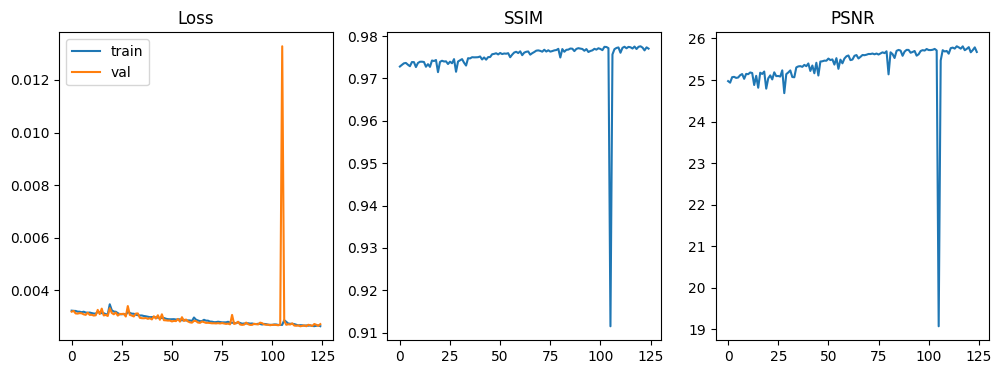

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.plot(train_losses,label="train")
plt.plot(val_losses,label="val")
plt.title("Loss")
plt.legend()

plt.subplot(1,3,2)
plt.plot(ssim_history)
plt.title("SSIM")

plt.subplot(1,3,3)
plt.plot(psnr_history)
plt.title("PSNR")

plt.show()

In [39]:
best_ssim = max(ssim_history)
best_psnr = max(psnr_history)

print("Best SSIM:", best_ssim)
print("Best PSNR:", best_psnr)

Best SSIM: 0.9776110630450947
Best PSNR: 25.811553425482543


In [40]:
if not os.path.exists(save_path):
    print(f"Error: The file {save_path} does not exist at all.")
elif os.path.isdir(save_path):
    print(f"Error: {save_path} is a directory, not a file.")
else:
    size_mb = os.path.getsize(save_path) / (1024 * 1024)
    print(f"File size: {size_mb:.2f} MB")
    if size_mb < 1.0:
        print("Fatal: The file is way too small to contain your model weights. It is corrupted.")

File size: 29.42 MB


In [41]:
if not os.path.isfile(save_path):
    raise FileNotFoundError(
        f"Fatal: No valid checkpoint found at '{save_path}'. "
        "Ensure the training loop executed and saved the model successfully."
    )

print(f"Loading best model weights from: {save_path}")

# Load the state dictionary directly onto the target device
model.load_state_dict(torch.load(save_path, map_location=device, weights_only=True))

# Lock the network for inference (disables dropout, freezes batch norm)
model.eval()

print("Model loaded and locked in evaluation mode.")

Loading best model weights from: working/StandardUNetRestoration_with_MSE_loss_no_augmentation/best_model.pth
Model loaded and locked in evaluation mode.


In [42]:
save_path

'working/StandardUNetRestoration_with_MSE_loss_no_augmentation/best_model.pth'

In [43]:
parent_dir = os.path.dirname(save_path)

In [44]:
# test_dir = "/kaggle/input/competitions/ExeBit_kla_ai_hack/KLA AI - HACK/test/NoisyLR"
# save_dir = "/kaggle/working/submission"
test_dir = "ExeBit_kla_ai_hack/KLA AI - HACK/test/NoisyLR"
save_dir = os.path.join(parent_dir, 'submissions')

os.makedirs(save_dir, exist_ok=True)
print(f"Submissions directory ready at: {save_dir}")
files = sorted(os.listdir(test_dir))


with torch.no_grad():

    for file in files:

        path = os.path.join(test_dir, file)

        lr = np.load(path)

        lr = torch.from_numpy(lr).float().unsqueeze(0).unsqueeze(0)
        lr = torch.clamp(lr,0,1)

        lr = lr.to(device)

        pred = model(lr)

        pred = pred.squeeze().cpu().numpy()

        pred = np.clip(pred,0,1).astype(np.float32)

        save_name = file
        save_path = os.path.join(save_dir, save_name)

        np.save(save_path, pred)

Submissions directory ready at: working/StandardUNetRestoration_with_MSE_loss_no_augmentation/submissions


In [45]:
import base64
import pandas as pd
from io import BytesIO

rows = []
csv_path = os.path.join(save_dir, "submission.csv")
files = sorted([f for f in os.listdir(save_dir) if f.endswith(".npy")])

for idx, file in enumerate(files, start=1):

    path = os.path.join(save_dir, file)

    arr = np.load(path)

    buffer = BytesIO()
    np.save(buffer, arr)

    encoded = base64.b64encode(buffer.getvalue()).decode()

    rows.append({
        "id": idx,
        "npy_base64": encoded
    })

df = pd.DataFrame(rows)

df.to_csv(csv_path, index=False)
print("Submission created with", len(df), "rows at :", csv_path)

Submission created with 200 rows at : working/StandardUNetRestoration_with_MSE_loss_no_augmentation/submissions/submission.csv


In [46]:
total_params = sum(p.numel() for p in model.parameters())
print("Total parameters:", total_params)

Total parameters: 7699009
